In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import warnings
import pandas as pd
from scipy.stats import kruskal, wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import seaborn as sns
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")

#set_session(tf.Session(config=config))



matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.size'] = 6

plt.rcParams['axes.unicode_minus'] = False 

elec_type_list = ["all_elecs", "downsampled_all_elecs",'downsample_covert_sig', 'downsample_overt_sig', 
                  'SHARED', 'SASI', 'only_SASI', 
                  'covert_sig', 'overt_sig', 'SI-specific', 'SA-specific']

In [2]:
bands = ['beta1','high_gamma','hgb1']
reading_name_list = ['covert',"overt"]
HS_list = [45,47,48,50,54,71,73,76,78]

**Data handling:** `workspace/Source_Data.xlsx` is used as a read-only input.

# Ext. Fig. 8j

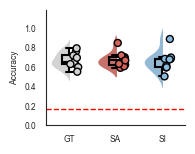

Group statistics (median, IQR, sample size):
SI: Median=0.6786, Q1=0.5980, Q3=0.6849, N=9
GT: Median=0.6479, Q1=0.6308, Q3=0.7192, N=9
SA: Median=0.6684, Q1=0.6230, Q3=0.7014, N=9

Kruskal-Wallis: H=0.4480, p=0.7993

Pairwise Wilcoxon tests:
SI vs GT: raw p=0.9102, FDR=0.9102, significant=False
SI vs SA: raw p=0.4961, FDR=0.9102, significant=False
GT vs SA: raw p=0.8203, FDR=0.9102, significant=False

Comparison with chance:
SI: U=81.0000, p=0.0003331
GT: U=81.0000, p=0.0003331
SA: U=81.0000, p=0.0003331


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Rectangle
import seaborn as sns

from scipy.stats import kruskal, wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Ext. Fig. 8j"
)

mean_acc_df = (
    source_df[source_df["Type"]=="Observed"]
    .rename(columns={
        "Subject":"HS",
        "Task":"task",
        "Accuracy":"acc"
    })
)

chance_mean_acc_df = (
    source_df[source_df["Type"]=="Chance"]
    .rename(columns={
        "Subject":"HS",
        "Task":"task",
        "Accuracy":"acc"
    })
)

# =====================================================
# Configure the plot.
# =====================================================

matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

order = ["GT", "SA", "SI"]

palette = {
    "GT": "lightgrey",
    "SA": "#D5645B",
    "SI": "#88BBDF"
}

figsize = (1.8, 1.5)

plt.figure(figsize=figsize)
sns.set_style("white")

ax = sns.violinplot(
    x="task",
    y="acc",
    data=mean_acc_df,
    order=order,
    palette=palette,
    dodge=False,
    scale="width",
    inner=None,
    linewidth=1
)

sns.despine()
plt.legend([], [], frameon=False)

# Draw the half-violin distribution.
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        Rectangle(
            (x0, y0),
            width/2,
            height,
            transform=ax.transData
        )
    )
    violin.set_edgecolor(None)

# Overlay the observed-value boxplot.
sns.boxplot(
    x="task",
    y="acc",
    data=mean_acc_df,
    order=order,
    showfliers=False,
    width=0.3,
    saturation=1,
    ax=ax,
    boxprops={
        "zorder":3,
        "facecolor":"none",
        "edgecolor":"black"
    },
    whiskerprops={"color":"black"},
    capprops={"color":"black"},
    medianprops={"color":"black"}
)

# Plot chance-level values.
plt.axhline(
    y=0.17,
    color="red",
    linestyle="--",
    linewidth=1
)

plt.ylim(0,1.19)

# Plot individual participant values.
old_len = len(ax.collections)

sns.stripplot(
    x="task",
    y="acc",
    data=mean_acc_df,
    order=order,
    palette=palette,
    dodge=False,
    ax=ax,
    size=5,
    edgecolor="black",
    linewidth=1
)

for dots in ax.collections[old_len:]:
    dots.set_offsets(
        dots.get_offsets() + np.array([0.12,0])
    )

ax.set_ylabel("Accuracy")
ax.set_xlabel("")

plt.savefig(
    clean_data_path + "figures_R3/Ext. Fig. 8j.pdf",
    transparent=True,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Calculate statistical tests.
# =====================================================

tasks = mean_acc_df["task"].unique()

print("Group statistics (median, IQR, sample size):")

for task in tasks:
    d = mean_acc_df[
        mean_acc_df["task"]==task
    ]["acc"]

    print(
        f"{task}: "
        f"Median={d.median():.4f}, "
        f"Q1={d.quantile(0.25):.4f}, "
        f"Q3={d.quantile(0.75):.4f}, "
        f"N={len(d)}"
    )

H, p = kruskal(*[
    mean_acc_df[
        mean_acc_df["task"]==t
    ]["acc"]
    for t in tasks
])

print(f"\nKruskal-Wallis: H={H:.4f}, p={p:.4g}")

pairwise_p = []
pairs = []
valid_pairs = []

for t1, t2 in combinations(tasks,2):

    d1 = mean_acc_df[
        mean_acc_df["task"]==t1
    ]["acc"]

    d2 = mean_acc_df[
        mean_acc_df["task"]==t2
    ]["acc"]

    if len(d1)==len(d2):
        _, pval = wilcoxon(
            d1,
            d2,
            alternative="two-sided"
        )
        pairwise_p.append(pval)
        valid_pairs.append((t1,t2))

if pairwise_p:

    reject, p_corr, _, _ = multipletests(
        pairwise_p,
        method="fdr_bh"
    )

    print("\nPairwise Wilcoxon tests:")

    for (t1,t2), p0, pfdr, sig in zip(
        valid_pairs,
        pairwise_p,
        p_corr,
        reject
    ):
        print(
            f"{t1} vs {t2}: "
            f"raw p={p0:.4g}, "
            f"FDR={pfdr:.4g}, "
            f"significant={sig}"
        )

print("\nComparison with chance:")

for task in tasks:

    obs = mean_acc_df[
        mean_acc_df["task"]==task
    ]["acc"]

    chance = chance_mean_acc_df[
        chance_mean_acc_df["task"]==task
    ]["acc"]

    stat, p = mannwhitneyu(
        obs,
        chance,
        alternative="two-sided"
    )

    print(
        f"{task}: "
        f"U={stat:.4f}, "
        f"p={p:.4g}"
    )

# Ext. Fig. 8i

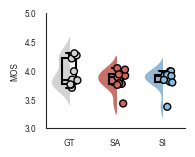

Group statistics (median, IQR, sample size):
SI: Median=3.9045, Q1=3.8082, Q3=3.9239, N=9
GT: Median=3.8425, Q1=3.7592, Q3=4.2098, N=9
SA: Median=3.8811, Q1=3.7692, Q3=3.9337, N=9

Kruskal-Wallis test
H = 0.4127, p = 0.8135

Pairwise Wilcoxon signed-rank tests
SI vs GT: raw p=0.2031, FDR p=0.3047, significant=False
SI vs SA: raw p=0.9102, FDR p=0.9102, significant=False
GT vs SA: raw p=0.09766, FDR p=0.293, significant=False


In [4]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
import pandas as pd

from scipy.stats import kruskal, wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# =====================================================
# Configure Matplotlib.
# =====================================================

matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Ext. Fig. 8i"
)

mean_acc_df = source_df.rename(columns={
    "Subject": "HS",
    "Task": "task",
    "MOS": "acc"
})

# =====================================================
# Configure the figure.
# =====================================================

order = ["GT", "SA", "SI"]

palette = {
    "GT": "lightgrey",
    "SA": "#D5645B",
    "SI": "#88BBDF"
}

fig_save_path = clean_data_path + "figures_R3/Ext. Fig. 8i.pdf"

# =====================================================
# Create the plot.
# =====================================================

plt.figure(figsize=(1.8, 1.5))
sns.set_style("white")

ax = sns.violinplot(
    x="task",
    y="acc",
    data=mean_acc_df,
    order=order,
    palette=palette,
    dodge=False,
    scale="width",
    inner=None,
    linewidth=1
)

sns.despine()
plt.legend([], [], frameon=False)

# Draw the half-violin distribution.
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        patches.Rectangle(
            (x0, y0),
            width / 2,
            height,
            transform=ax.transData
        )
    )
    violin.set_edgecolor(None)

# Overlay the boxplot.
sns.boxplot(
    x="task",
    y="acc",
    data=mean_acc_df,
    order=order,
    width=0.3,
    showfliers=False,
    saturation=1,
    ax=ax,
    boxprops={
        "zorder": 3,
        "facecolor": "none",
        "edgecolor": "black"
    },
    whiskerprops={"color": "black"},
    capprops={"color": "black"},
    medianprops={"color": "black"}
)

# Plot individual participant values.
old_len = len(ax.collections)

sns.stripplot(
    x="task",
    y="acc",
    data=mean_acc_df,
    order=order,
    palette=palette,
    dodge=False,
    size=5,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

for dots in ax.collections[old_len:]:
    dots.set_offsets(
        dots.get_offsets() + np.array([0.12, 0])
    )

plt.ylim(3, 5)

ax.set_ylabel("MOS")
ax.set_xlabel("")

plt.savefig(
    fig_save_path,
    transparent=True,
    bbox_inches="tight",
    format="pdf"
)

plt.show()

# =====================================================
# Calculate descriptive statistics.
# =====================================================

tasks = mean_acc_df["task"].unique()

print("Group statistics (median, IQR, sample size):")

for task in tasks:
    values = mean_acc_df.loc[
        mean_acc_df["task"] == task,
        "acc"
    ]

    print(
        f"{task}: "
        f"Median={values.median():.4f}, "
        f"Q1={values.quantile(0.25):.4f}, "
        f"Q3={values.quantile(0.75):.4f}, "
        f"N={len(values)}"
    )

# =====================================================
# Run the Kruskal-Wallis test.
# =====================================================

grouped = [
    mean_acc_df.loc[
        mean_acc_df["task"] == task,
        "acc"
    ]
    for task in tasks
]

H, p = kruskal(*grouped)

print("\nKruskal-Wallis test")
print(f"H = {H:.4f}, p = {p:.4g}")

# =====================================================
# Run pairwise Wilcoxon signed-rank tests.
# =====================================================

print("\nPairwise Wilcoxon signed-rank tests")

pairs = list(combinations(tasks, 2))

raw_p = []
valid_pairs = []

for t1, t2 in pairs:

    d1 = (
        mean_acc_df[mean_acc_df["task"] == t1]
        .sort_values("HS")["acc"]
        .values
    )

    d2 = (
        mean_acc_df[mean_acc_df["task"] == t2]
        .sort_values("HS")["acc"]
        .values
    )

    if len(d1) == len(d2):

        stat, pvalue = wilcoxon(
            d1,
            d2,
            alternative="two-sided"
        )

        raw_p.append(pvalue)
        valid_pairs.append((t1, t2))

    else:
        print(f"{t1} vs {t2}: unequal sample size")

if len(raw_p):

    reject, p_fdr, _, _ = multipletests(
        raw_p,
        method="fdr_bh"
    )

    for (t1, t2), p0, pfdr, sig in zip(
        valid_pairs,
        raw_p,
        p_fdr,
        reject
    ):

        print(
            f"{t1} vs {t2}: "
            f"raw p={p0:.4g}, "
            f"FDR p={pfdr:.4g}, "
            f"significant={sig}"
        )

# Ext. Fig. 8k

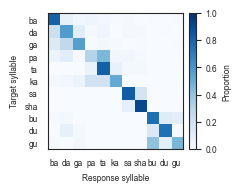

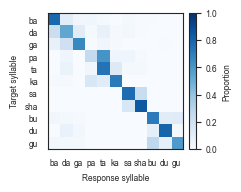

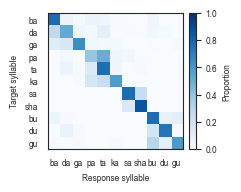

    task1  task2  spearman_r       p_value
0  covert  overt    0.896889  5.556948e-44
1  covert    ori    0.872366  8.584228e-39
2   overt    ori    0.884442  3.354240e-41


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# =====================================================
# Configure Matplotlib.
# =====================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Ext. Fig. 8k"
)

valid_syllables = [
    "ba", "da", "ga",
    "pa", "ta", "ka",
    "sa", "sha",
    "bu", "du", "gu"
]

tasks = source_df["Task"].unique()

cm_norm_dict = {}

# =====================================================
# Plot the confusion matrices.
# =====================================================

for task in tasks:

    sub_df = source_df[source_df["Task"] == task]

    cm = confusion_matrix(
        sub_df["Target syllable"],
        sub_df["Response syllable"],
        labels=valid_syllables
    )

    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    cm_norm_dict[task] = cm_norm

    fig, ax = plt.subplots(figsize=(2.3, 2.3))

    im = ax.imshow(
        cm_norm,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(np.arange(len(valid_syllables)))
    ax.set_yticks(np.arange(len(valid_syllables)))

    ax.set_xticklabels(valid_syllables)
    ax.set_yticklabels(valid_syllables)

    ax.set_xlabel("Response syllable")
    ax.set_ylabel("Target syllable")

    cbar = plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label("Proportion")
    cbar.ax.tick_params(labelsize=6)

    ax.tick_params(axis="both", labelsize=6)

    plt.tight_layout(pad=0.5)

    pdf_path = (
        clean_data_path
        + f"figures_R3/Ext. Fig. 8k_{task}.pdf"
    )

    plt.savefig(
        pdf_path,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()

from scipy.stats import spearmanr
import pandas as pd

tasks = list(cm_norm_dict.keys())
results = []

for i in range(len(tasks)):
    for j in range(i + 1, len(tasks)):
        t1, t2 = tasks[i], tasks[j]

        cm1 = cm_norm_dict[t1].flatten()
        cm2 = cm_norm_dict[t2].flatten()

        r, p = spearmanr(cm1, cm2)

        results.append({
            'task1': t1,
            'task2': t2,
            'spearman_r': r,
            'p_value': p
        })

sim_df = pd.DataFrame(results)
print(sim_df)